In [2]:
import numpy as np
from scipy.sparse import diags
import time
import matplotlib.pyplot as plt

In [6]:
def K_matrix(h):
    k_11 = 1/h + h/3
    k_12 = -1/h + h/6
    return k_11, k_12

def A_upper_algo_1(h_n):
    n = h_n.shape[0]+1
    A = np.zeros([n,n])
    for i in range(n-1):
        h = h_n[i]
        k_11, k_12 = K_matrix(h)
        A[i,i] += k_11
        A[i,i+1] = k_12
        A[i+1,i+1] = k_11
    return A

def A_upper_algo_2(A,c,d):
    n = A_upper.shape[0]
    b = np.zeros(n)
    b[0] = c
    b[1] = b[1]-A[0,1]*c

    A[0,0] = 1
    A[0,1] = 0

    b[n-1] = d
    b[n-2] = b[n-2]-A[n-2,n-1]*d
    A[n-1,n-1] = 1
    A[n-2,n-1] = 0
    return A,b

def mesh_length(nodes):
    n = nodes.shape[0]
    h = np.zeros(n-1)
    for i in range(n-1):
        h[i] = nodes[i+1]-nodes[i]
    return h


def glob_basis_func(x,nodes,i,h=None):
    if h is None:
        h = mesh_length(nodes)
    n = nodes.shape[0]

    #first find lower bound
    if i == 0:
        lower = 0
    else: lower = nodes[i-1]

    #find upper bound
    if i == n-1:
        upper = nodes[n-1]
    else: upper = nodes[i+1]

    if lower <= x and x <= upper:
        if i == 0:
            return 1-(x-nodes[i])/h[i]
        if i == n-1:
            return (x-nodes[i-1])/h[i-1]
        if i < n-1:
            if x < nodes[i]:
                return (x-nodes[i-1])/h[i-1]
            else: return 1- (x-nodes[i])/h[i]
    else: return 0


  

In [13]:
t0 = time.time()

c = 1
d = np.exp(2)
nodes =  np.array([0.0, 0.2, 0.4, 0.6, 0.7, 0.9, 1.4, 1.5, 1.8, 1.9, 2.0])

h_cons = mesh_length(nodes)

A_upper = A_upper_algo_1(h_cons)
#print("Algo1", A_upper)
A_upper,b = A_upper_algo_2(A_upper,c,d)
print("b\n", b)

A_sparse = diags(
    diagonals=[A_upper.diagonal(1), A_upper.diagonal(), A_upper.diagonal(1)],
    offsets=[-1, 0, 1],
    format="csr"
)
A_full = A_sparse.toarray()
print("A_full", A_upper)

u_hat = np.linalg.solve(A_full,b)
t1 = time.time()
print(t1-t0)
print(u_hat)

b
 [ 1.          4.96666667  0.          0.          0.          0.
  0.          0.          0.         73.76741005  7.3890561 ]
A_full [[ 1.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.        ]
 [ 0.         10.13333333 -4.96666667  0.          0.          0.
   0.          0.          0.          0.          0.        ]
 [ 0.          0.         10.13333333 -4.96666667  0.          0.
   0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.         15.1        -9.98333333  0.
   0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.         15.1        -4.96666667
   0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          7.23333333
  -1.91666667  0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
  12.2 

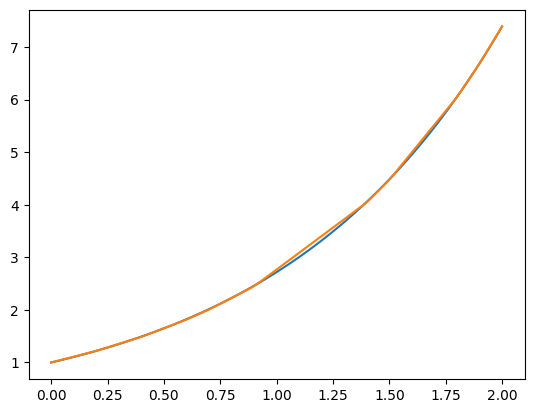

In [ ]:
x = np.linspace(0,2,100)
u_observations = np.exp(nodes)
u_analytical = np.exp(x)
u_interpol = sum(u_observations[i]* np.array([glob_basis_func(xi, nodes, i) for xi in x]) for i in range(nodes.shape[0]))
u_fem = sum(u_hat[i] * np.array([glob_basis_func(xi, nodes, i) for xi in x]) for i in range(nodes.shape[0]))
plt.plot(x, u_analytical, label="Analytical solution")
plt.plot(x, u_fem, label="FEM solution")
plt.plot(x,u_interpol, label="Interpolation", color = "black")
plt.show()

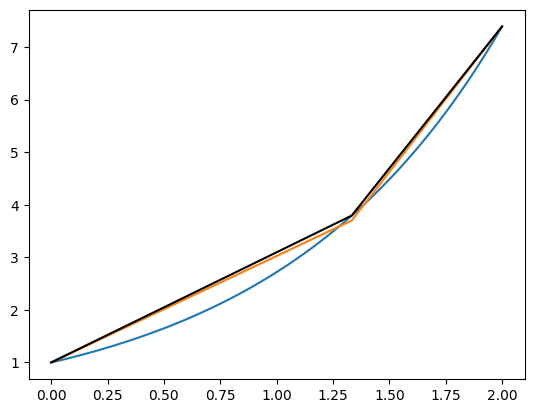

In [47]:
t0 = time.time()
c = 1
d = np.exp(2)
nodes = np.array([0,4/3,2])
h_cons = mesh_length(nodes)

A_upper = A_upper_algo_1(h_cons)
A_upper,b = A_upper_algo_2(A_upper,c,d)
A_sparse = diags(
    diagonals=[A_upper.diagonal(1), A_upper.diagonal(), A_upper.diagonal(1)],
    offsets=[-1, 0, 1],
    format="csr"
)
A_full = A_sparse.toarray()
u_hat = np.linalg.solve(A_full,b)

x = np.linspace(0,2,100)
u_observations = np.exp(nodes)
u_analytical = np.exp(x)
u_interpol = sum(u_observations[i]* np.array([glob_basis_func(xi, nodes, i) for xi in x]) for i in range(nodes.shape[0]))
u_fem = sum(u_hat[i] * np.array([glob_basis_func(xi, nodes, i) for xi in x]) for i in range(nodes.shape[0]))
plt.plot(x, u_analytical, label="Analytical solution")
plt.plot(x, u_fem, label="FEM solution")
plt.plot(x,u_interpol, label="Interpolation", color = "black")